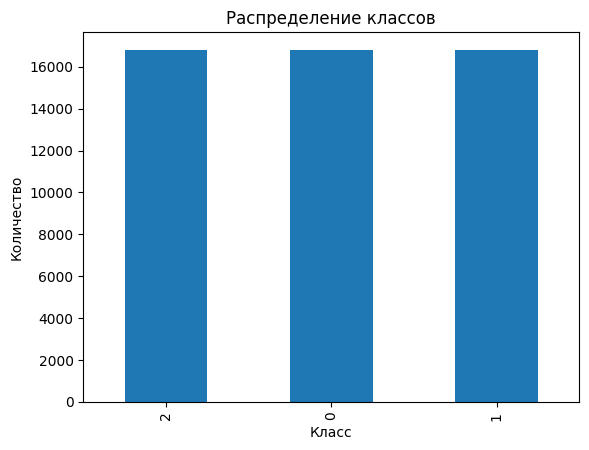

       Soil_Type  Soil_pH  Soil_Moisture  Organic_Carbon  \
364549     Sandy     7.72          14.41            0.60   
121489     Loamy     7.70          15.91            1.05   
96028       Clay     7.76          19.39            1.38   
312393      Clay     7.97          11.52            0.56   
154261      Clay     5.59          19.82            1.57   
...          ...      ...            ...             ...   
17674      Loamy     7.42          38.49            1.46   
109962      Clay     6.40          41.89            1.26   
168483      Silt     5.81          56.07            1.53   
174087      Silt     7.43          61.14            1.11   
414039      Silt     5.46          49.35            0.39   

        Electrical_Conductivity  Temperature_C  Humidity  Rainfall_mm  \
364549                     0.20          32.88     69.83      1495.92   
121489                     1.70          30.66     84.84      2344.60   
96028                      1.08          33.73     30.38    

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8029 - loss: 0.4473
Epoch 2/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8446 - loss: 0.3667
Epoch 3/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8489 - loss: 0.3607
Epoch 4/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8542 - loss: 0.3496
Epoch 5/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8738 - loss: 0.3113
Epoch 6/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.8864 - loss: 0.2855
Epoch 7/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8916 - loss: 0.2757
Epoch 8/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8963 - loss: 0.2660
Epoch 9/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9025 - loss: 0.2532
Epoch 10/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9076 - loss: 0.2399
Epoch 11/30
3152/3152 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9130 - loss: 0.2280
Epoch 12/30
3152/3152 ━━━━━━━

In [3]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import make_column_transformer
from xgboost import XGBClassifier

ds=pd.read_csv("train.csv")
ds.loc[ds["Mulching_Used"]== 'Yes', "Mulching_Used"]=1
ds.loc[ds["Mulching_Used"]== 'No', "Mulching_Used"]=0
ds = ds.drop("id", axis=1)
ds=ds.dropna()

min_count = ds["Irrigation_Need"].value_counts().min()
ds = ds.groupby("Irrigation_Need").sample(n=min_count, random_state=42)

le = LabelEncoder()

X = ds.drop(columns=["Irrigation_Need"])
y = le.fit_transform(ds["Irrigation_Need"])

cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

ct=make_column_transformer(
    (MinMaxScaler(),num_cols),
    (OneHotEncoder(handle_unknown="ignore"), cat_cols)
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

#ct=make_column_transformer(
#    (MinMaxScaler(),['Soil_Moisture','Soil_pH','Electrical_Conductivity','Rainfall_mm','Field_Area_hectare','Previous_Irrigation_mm','Organic_Carbon','Temperature_C','Humidity','Sunlight_Hours']),
#    (OneHotEncoder(handle_unknown="ignore"), ['Soil_Type', 'Crop_Type','Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source'])
#)

X_train_normalized = ct.fit_transform(X_train)
X_test_normalized = ct.transform(X_test)

import matplotlib.pyplot as plt

pd.Series(y_train).value_counts().plot(kind='bar')

plt.xlabel('Класс')
plt.ylabel('Количество')
plt.title('Распределение классов')
plt.show()
print(X)

tensorflow.random.set_seed(17)

model=keras.Sequential([
    layers.Dense(10, activation="relu", input_dim=X_train_normalized.shape[1]),
    layers.Dense(15, activation="relu"),
    layers.Dense(3, activation=keras.activations.softmax),
])
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(X_train_normalized, y_train, epochs=30, batch_size=16)

y_hat = model.predict(X_test_normalized)
y_hat = np.argmax(y_hat, axis=1)

report = classification_report(y_test, y_hat)
print(report)
model.save("model.keras")

In [11]:
from tensorflow import keras
model = keras.models.load_model("model_94.keras")

ds=pd.read_csv("train.csv")
ds.loc[ds["Mulching_Used"]== 'Yes', "Mulching_Used"]=1
ds.loc[ds["Mulching_Used"]== 'No', "Mulching_Used"]=0
ds = ds.drop(columns="id")
ds=ds.dropna()


cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

ct=make_column_transformer(
    (MinMaxScaler(),num_cols),
    (OneHotEncoder(handle_unknown="ignore"), cat_cols)
)
ds_normilized=ct.fit_transform(ds)
prediction=model.predict(ds_normilized)
prediction=np.argmax(prediction, axis=1)
print(prediction)

19688/19688 ━━━━━━━━━━━━━━━━━━━━ 23s 1ms/step
[1 1 1 ... 0 1 1]
